# Example 17: Satellite-to-Satellite Angles-Only OD — authored in Python

A minimal orbit-determination scenario **built entirely in Python** — the estimator
application *and* the measurement model are Python classes, driven by the same C++
``pnt.Simulation`` as every other example. This is the template for prototyping your own
scenario without touching C++.

Two ``Spacecraft`` share the lunar environment. An **observer** measures only the **bearing**
(unit line-of-sight direction) to a **target** whose ephemeris is treated as **known**, and an
EKF on the observer estimates the observer's own 6-state orbit $[\mathbf r,\mathbf v]$ (no clock
— angles are clock-independent). Measuring a *direction* to a *known* landmark is well-posed and
converges; estimating an *unknown* target's **range** from bearings alone is the classic
ill-posed angles-only problem, and is not attempted.

The pieces (see the *How to Create a New Simulation* page → "Working in Python"):

* a **Measurement** — subclass ``pnt.Measurement``, implement ``compute(self, x) -> (z, H, R)``;
* an **Application** — subclass ``pnt.Application`` (an EKF in numpy), registered with
  ``pnt.register_application`` and referenced by ``class:`` in ``configs/sat_bearing_odts.yaml``;
* reused as-is: the ``Spacecraft`` agents, the ``pnt.NBodyDynamics`` force model (built and
  propagated with STM from Python), and Monte-Carlo (looped here over seeds).

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

for _base in [Path.cwd(), *Path.cwd().parents]:
    if (_base / "python" / "pylupnt" / "__init__.py").exists():
        sys.path.insert(0, str((_base / "python").resolve()))
        if (_base / "data" / "LuPNT_data").is_dir():
            os.environ["LUPNT_DATA_PATH"] = str(
                (_base / "data" / "LuPNT_data").resolve()
            )
        break
import yaml
import pylupnt as pnt

print(f"pylupnt loaded from: {pnt.__file__}")

[00.01][PyLuPNT] Initializing


pylupnt loaded from: /path/to/LuPNT/python/pylupnt/__init__.py


## 1. Author the measurement model in Python

A ``pnt.Measurement`` subclass returns the predicted observable $z=h(x)$, its Jacobian
$H=\partial h/\partial x$, and the noise covariance $R$. ``m.evaluate(x)`` runs it through the
C++ base (the same path a filter uses), so the **same class** both *generates* an observation
(apply to a truth state, add noise) and *predicts* one (apply to the filter state).

In [2]:
class BearingMeasurement(pnt.Measurement):
    "Unit line-of-sight (bearing) to a known target position."

    def __init__(self, sigma_rad):
        pnt.Measurement.__init__(self)
        self.sigma = sigma_rad
        self.target = np.zeros(3)  # set per-epoch to the target truth position

    def compute(self, x):  # -> (z = h(x), H = dh/dx, R)
        d = self.target - x[:3]
        rn = np.linalg.norm(d)
        u = d / rn
        H = np.zeros((3, 6))
        H[:, :3] = -(np.eye(3) - np.outer(u, u)) / rn
        return u, H, self.sigma**2 * np.eye(3)

## 2. Author the estimator application in Python

A ``pnt.Application`` subclass. ``setup()`` builds a filter force model (``pnt.NBodyDynamics``)
and the measurement; ``step(t)`` reads truth through the host agent, runs one EKF predict/update
(propagating with STM via ``dyn.propagate_stm``), and stores results on ``self``. The engine
constructs it from the ``application:`` block of the config and calls ``step`` each epoch.

In [3]:
def make_dyn():
    d = pnt.NBodyDynamics()
    for b in (pnt.Body.Moon(8, 8), pnt.Body.Earth(), pnt.Body.Sun()):
        d.add_body(b)
    d.set_frame(pnt.Frame.MOON_CI)
    d.set_integrator(pnt.IntegratorType.RKF45)
    d.set_autodiff(True)
    return d


class PyAnglesOdtsApp(pnt.Application):
    def __init__(self, config):
        pnt.Application.__init__(self)
        self.target = config["target"]
        self.set_frequency(config.get("frequency", 1.0 / 60))
        self.sigma = np.radians(config.get("angle_sigma_arcsec", 2.0) / 3600.0)
        self.p0 = config.get("initial_position_sigma_m", 300.0)
        self.v0 = config.get("initial_velocity_sigma_mps", 0.3)
        self.qa = config.get("process_accel_sigma_mps2", 1e-6)
        self.rng = np.random.default_rng(config.get("seed", 42))
        self.times, self.est, self.truth, self.sig = [], [], [], []
        self._init = False

    def setup(self):
        pnt.Application.setup(self)  # base schedules step() at get_frequency()
        self.dyn = make_dyn()
        self.meas = BearingMeasurement(self.sigma)

    def step(self, t):
        if not self._init:  # capture initial truths once
            self.obs = np.asarray(self.get_agent().get_state_at(0.0))
            self.tgt = np.asarray(
                self.get_agent().get_world().get_state_at(self.target, 0.0)
            )
            self.x = (
                self.obs
                + np.r_[self.rng.normal(0, self.p0, 3), self.rng.normal(0, self.v0, 3)]
            )
            self.P = np.diag(np.r_[[self.p0**2] * 3, [self.v0**2] * 3])
            self._init, self._t = True, t
            self._log(t)
            return
        dt = t - self._t
        self.obs = np.asarray(
            self.dyn.propagate_stm(self.obs, float(self._t), float(t))[0]
        ).ravel()
        self.tgt = np.asarray(
            self.dyn.propagate_stm(self.tgt, float(self._t), float(t))[0]
        ).ravel()
        xf, F = self.dyn.propagate_stm(self.x, float(self._t), float(t))
        self.x = np.asarray(xf).ravel()
        F = np.asarray(F)
        self._t = t
        q = self.qa**2
        Q = q * np.block(
            [
                [dt**3 / 3 * np.eye(3), dt**2 / 2 * np.eye(3)],
                [dt**2 / 2 * np.eye(3), dt * np.eye(3)],
            ]
        )
        self.P = F @ self.P @ F.T + Q
        self.meas.target = self.tgt[:3]
        z = self.meas.evaluate(self.obs)[0] + self.rng.normal(
            0, self.sigma, 3
        )  # generate
        u, H, R = self.meas.evaluate(self.x)  # predict
        S = H @ self.P @ H.T + R
        K = self.P @ H.T @ np.linalg.inv(S)
        self.x = self.x + K @ (z - u)
        IKH = np.eye(6) - K @ H
        self.P = IKH @ self.P @ IKH.T + K @ R @ K.T
        self._log(t)

    def _log(self, t):
        self.times.append(t)
        self.est.append(self.x.copy())
        self.truth.append(self.obs.copy())
        self.sig.append(np.sqrt(np.diag(self.P)))

## 3. Register and run

Register the Python app, then hand the scenario config to ``pnt.Simulation``. We run a small
Monte-Carlo by looping the seed (each run is a couple of seconds), collecting one ensemble of
observer position errors.

In [4]:
pnt.register_application("PyAnglesOdtsApp", PyAnglesOdtsApp)

cfg_path = next(
    p / "configs" / "sat_bearing_odts.yaml"
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "configs" / "sat_bearing_odts.yaml").exists()
)
base_cfg = yaml.safe_load(open(cfg_path))

N_MC = 5
runs = []
for i in range(N_MC):
    cfg = yaml.safe_load(open(cfg_path))
    cfg["agents"]["observer"]["application"]["seed"] = 42 + i
    sim = pnt.Simulation(cfg)
    sim.run()
    runs.append(sim.get_agent("observer").get_application())

r0 = runs[0]
t_hr = np.asarray(r0.times) / 3600.0
perr = np.array(
    [
        np.linalg.norm(np.array(r.est)[:, :3] - np.array(r.truth)[:, :3], axis=1)
        for r in runs
    ]
)  # [N_MC, N]
print(f"{N_MC} Monte-Carlo runs")
print(
    f"Final observer position error (RMS over MC): {np.sqrt(np.mean(perr[:, -1]**2)):8.2f} m"
)
print(
    f"Arc   observer position error (RMS over MC): {np.sqrt(np.mean(perr**2)):8.2f} m"
)

[01.22][/path/to/LuPNT/output/sat_bearing_odts/sat_bearing_odts.h5] Output file: {}
[01.22][Simulation] Output file: /path/to/LuPNT/output/sat_bearing_odts/sat_bearing_odts.h5



[01.40][Simulation]  12%|█         | 12/100 [00:00<00:01, 59.9 it/s]


[01.40][Simulation]  24%|██        | 24/100 [00:00<00:01, 59.4 it/s]


[01.40][Simulation]  37%|███       | 37/100 [00:00<00:01, 61.3 it/s]


[01.40][Simulation]  62%|██████    | 62/100 [00:01<00:00, 61.5 it/s]


...

[08.09][Simulation]  22%|██        | 22/100 [00:00<00:01, 54.6 it/s]


[08.09][Simulation]  45%|████      | 45/100 [00:00<00:00, 55.9 it/s]


[08.09][Simulation]  70%|███████   | 70/100 [00:01<00:00, 58.0 it/s]


[08.09][Simulation]  93%|█████████ | 93/100 [00:01<00:00, 57.7 it/s]


[08.09][Simulation] 100%|██████████| 100/100 [00:01<00:00, 58.2 it/s]
5 Monte-Carlo runs
Final observer position error (RMS over MC):     6.31 m
Arc   observer position error (RMS over MC):    76.84 m


## 4. Convergence

**Left:** the ensemble position-error RMS (over the Monte-Carlo runs) — from the ~300 m a-priori
down to the metre level as the bearing geometry accumulates. **Right:** the per-axis error of one
run with the filter's own $3\sigma$ envelope (the estimate stays inside its covariance).

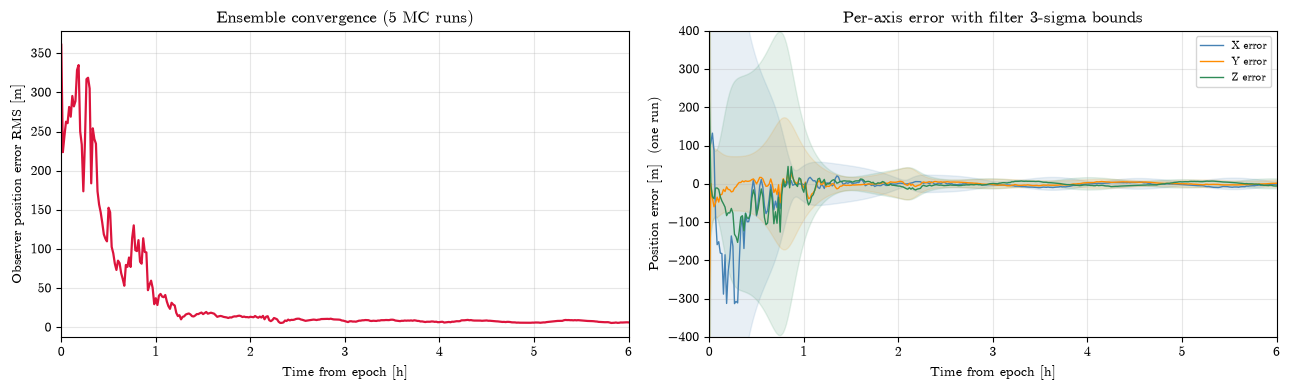

In [5]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4))
ax0.plot(t_hr, np.sqrt(np.mean(perr**2, axis=0)), color="crimson", lw=1.6)
ax0.set_xlabel("Time from epoch [h]")
ax0.set_ylabel("Observer position error RMS [m]")
ax0.set_title(f"Ensemble convergence ({N_MC} MC runs)")
ax0.set_xlim(0, t_hr[-1])
ax0.grid(True, alpha=0.3)

est = np.array(r0.est)
truth = np.array(r0.truth)
sig = np.array(r0.sig)
err = est - truth
for k, (lab, col) in enumerate(zip("XYZ", ["steelblue", "darkorange", "seagreen"])):
    ax1.plot(t_hr, err[:, k], color=col, lw=1.0, label=f"{lab} error")
    ax1.fill_between(t_hr, -3 * sig[:, k], 3 * sig[:, k], color=col, alpha=0.12)
ax1.set_xlabel("Time from epoch [h]")
ax1.set_ylabel("Position error [m]  (one run)")
ax1.set_title("Per-axis error with filter 3-sigma bounds")
ax1.set_xlim(0, t_hr[-1])
ax1.set_ylim(-400, 400)
ax1.legend(fontsize=8, loc="upper right")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Observer orbit

The observer's true trajectory (Moon-centered inertial, X–Y projection) colored by the estimate
error magnitude — the Python-authored EKF recovers the orbit to the metre level.

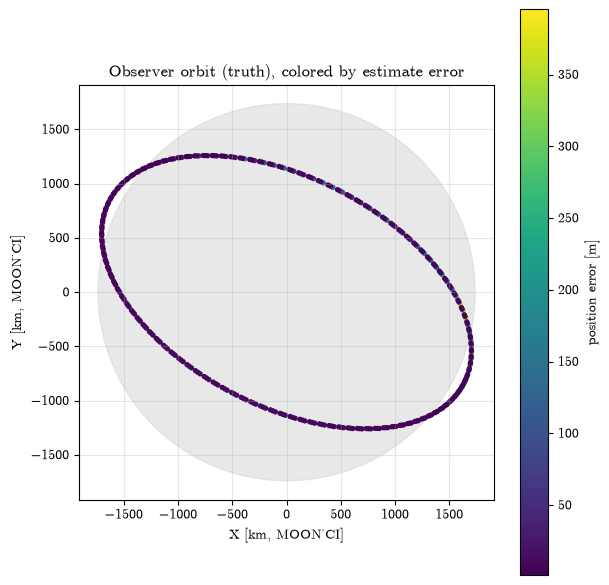

In [6]:
fig, ax = plt.subplots(figsize=(6.2, 6))
R_MOON_KM = 1737.4
th = np.linspace(0, 2 * np.pi, 200)
ax.fill(R_MOON_KM * np.cos(th), R_MOON_KM * np.sin(th), color="lightgray", alpha=0.5)
en = np.linalg.norm(est[:, :3] - truth[:, :3], axis=1)
sc = ax.scatter(truth[:, 0] / 1e3, truth[:, 1] / 1e3, c=en, cmap="viridis", s=8)
ax.set_aspect("equal")
ax.set_xlabel("X [km, MOON_CI]")
ax.set_ylabel("Y [km, MOON_CI]")
ax.set_title("Observer orbit (truth), colored by estimate error")
plt.colorbar(sc, ax=ax, label="position error [m]")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

* A complete OD scenario — the estimator **Application** and the **Measurement** model — authored
  in pure Python, driven by the C++ ``pnt.Simulation`` (``pnt.register_application`` +
  ``configs/sat_bearing_odts.yaml``).
* The filter reuses ``pnt.NBodyDynamics`` (built and propagated with STM from Python) and the
  ``Spacecraft`` agents; only new *observables* and *estimators* are written, and here in Python.
* Angles-only navigation against a **known** landmark is observable and converges (a few metres
  over a 6 h arc from a 300 m a-priori with 2 arcsec bearings).
* This is the smallest template for authoring your own scenario in Python — see *How to Create a
  New Simulation* → "Working in Python" for ``pnt.Agent`` and more.